In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.numbers to WA_Fn-UseC_-Telco-Customer-Churn.numbers


In [7]:
import pandas as pd
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [9]:
import numpy as np

# TotalCharges has blank spaces, so it loads as text. Convert to numbers
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df.isnull().sum()[df.isnull().sum() > 0])   # shows the missing values

df = df.dropna()                          # remove the few broken rows
df = df.drop("customerID", axis=1)        # ID is useless for prediction
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})   # Yes/No to 1/0

print(df.shape)
print("Churn rate:", round(df["Churn"].mean() * 100, 1), "%")

TotalCharges    11
dtype: int64
(7032, 20)
Churn rate: 26.6 %


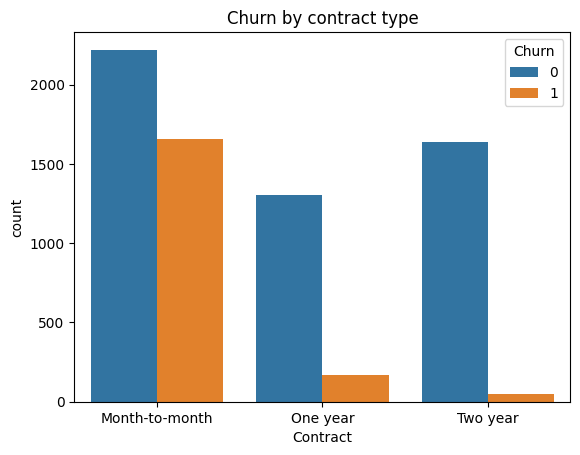

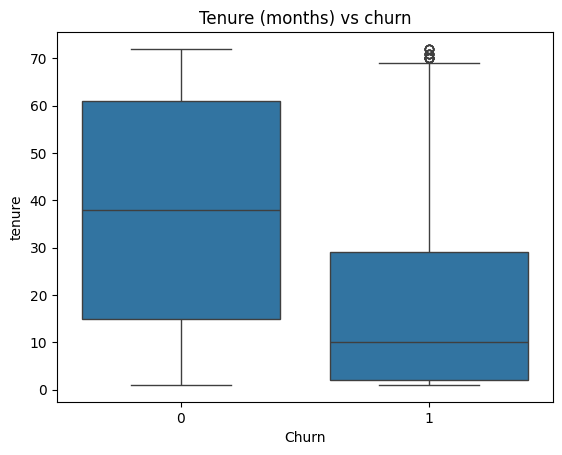

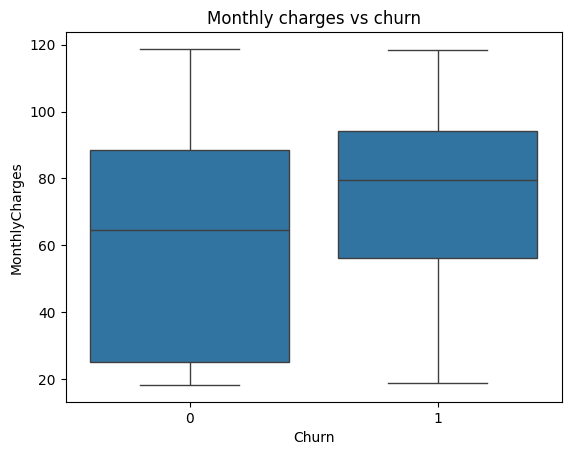

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by contract type")
plt.show()

sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure (months) vs churn")
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly charges vs churn")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)  # text columns to numbers
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            min_samples_leaf=5, random_state=42),
}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    print("=====", name, "| AUC:", round(auc, 3))
    print(classification_report(y_test, pred))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


===== Logistic Regression | AUC: 0.835
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

===== Random Forest | AUC: 0.836
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



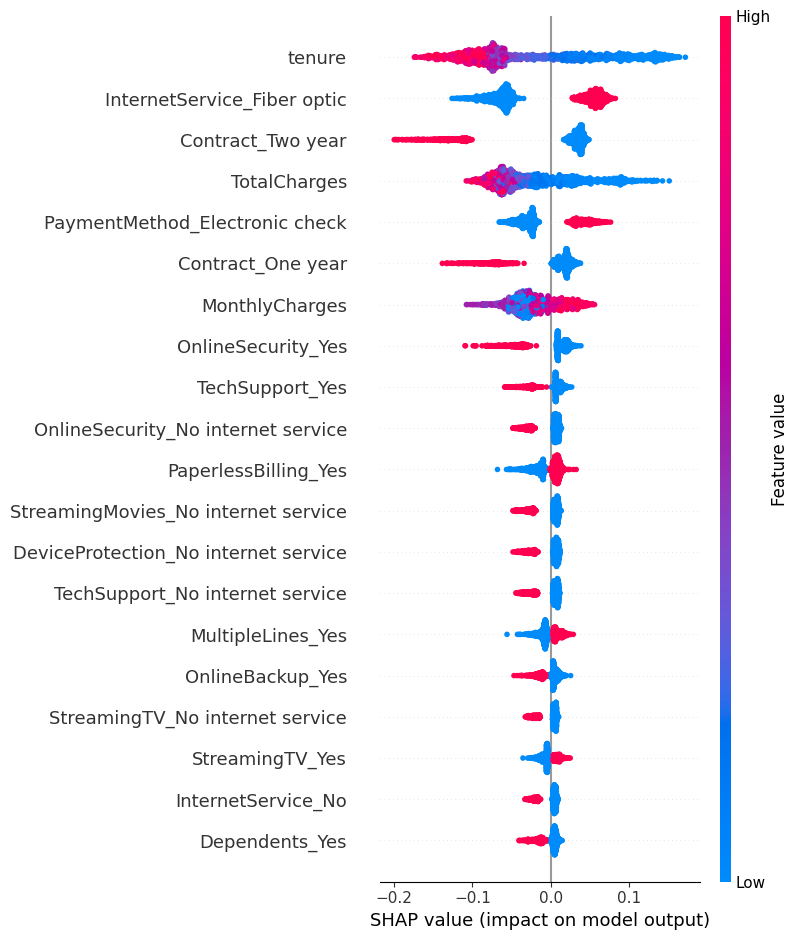

In [13]:
!pip install shap -q
import shap

rf = models["Random Forest"]
exp = shap.TreeExplainer(rf)(X_test)
if exp.values.ndim == 3:
    exp = exp[:, :, 1]          # take the "churn" class

shap.summary_plot(exp.values, X_test, show=False)
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()

In [14]:
probs = rf.predict_proba(X_test)[:, 1]
res = X_test.copy()
res["actual"] = y_test.values
res["flag"] = probs >= 0.5

# Assumptions (state these in your README)
offer_cost = 50        # € cost of retention offer per customer contacted
success_rate = 0.30    # 30% of at-risk customers accept and stay
months_kept = 12       # extra months of revenue if retained

contacted = res[res["flag"]]
cost = len(contacted) * offer_cost
saved = contacted[contacted["actual"] == 1]
revenue_saved = (saved["MonthlyCharges"] * months_kept * success_rate).sum()

print("Customers contacted:", len(contacted))
print("Campaign cost: €", round(cost))
print("Revenue saved: €", round(revenue_saved))
print("Net benefit: €", round(revenue_saved - cost))

Customers contacted: 511
Campaign cost: € 25550
Revenue saved: € 74929
Net benefit: € 49379
